<a href="https://colab.research.google.com/github/atharva-251122005/DS_Lab/blob/main/Exp_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_3311/10397193.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], x='Pclass', data=df, palette='viridis')
/tmp/ipykernel_3311/10397193.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 1], x='Sex', data=df, palette='magma')
/tmp/ipykernel_3311/10397193.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 1], x='Pclass', y='Age', data=df, palette='Set2')


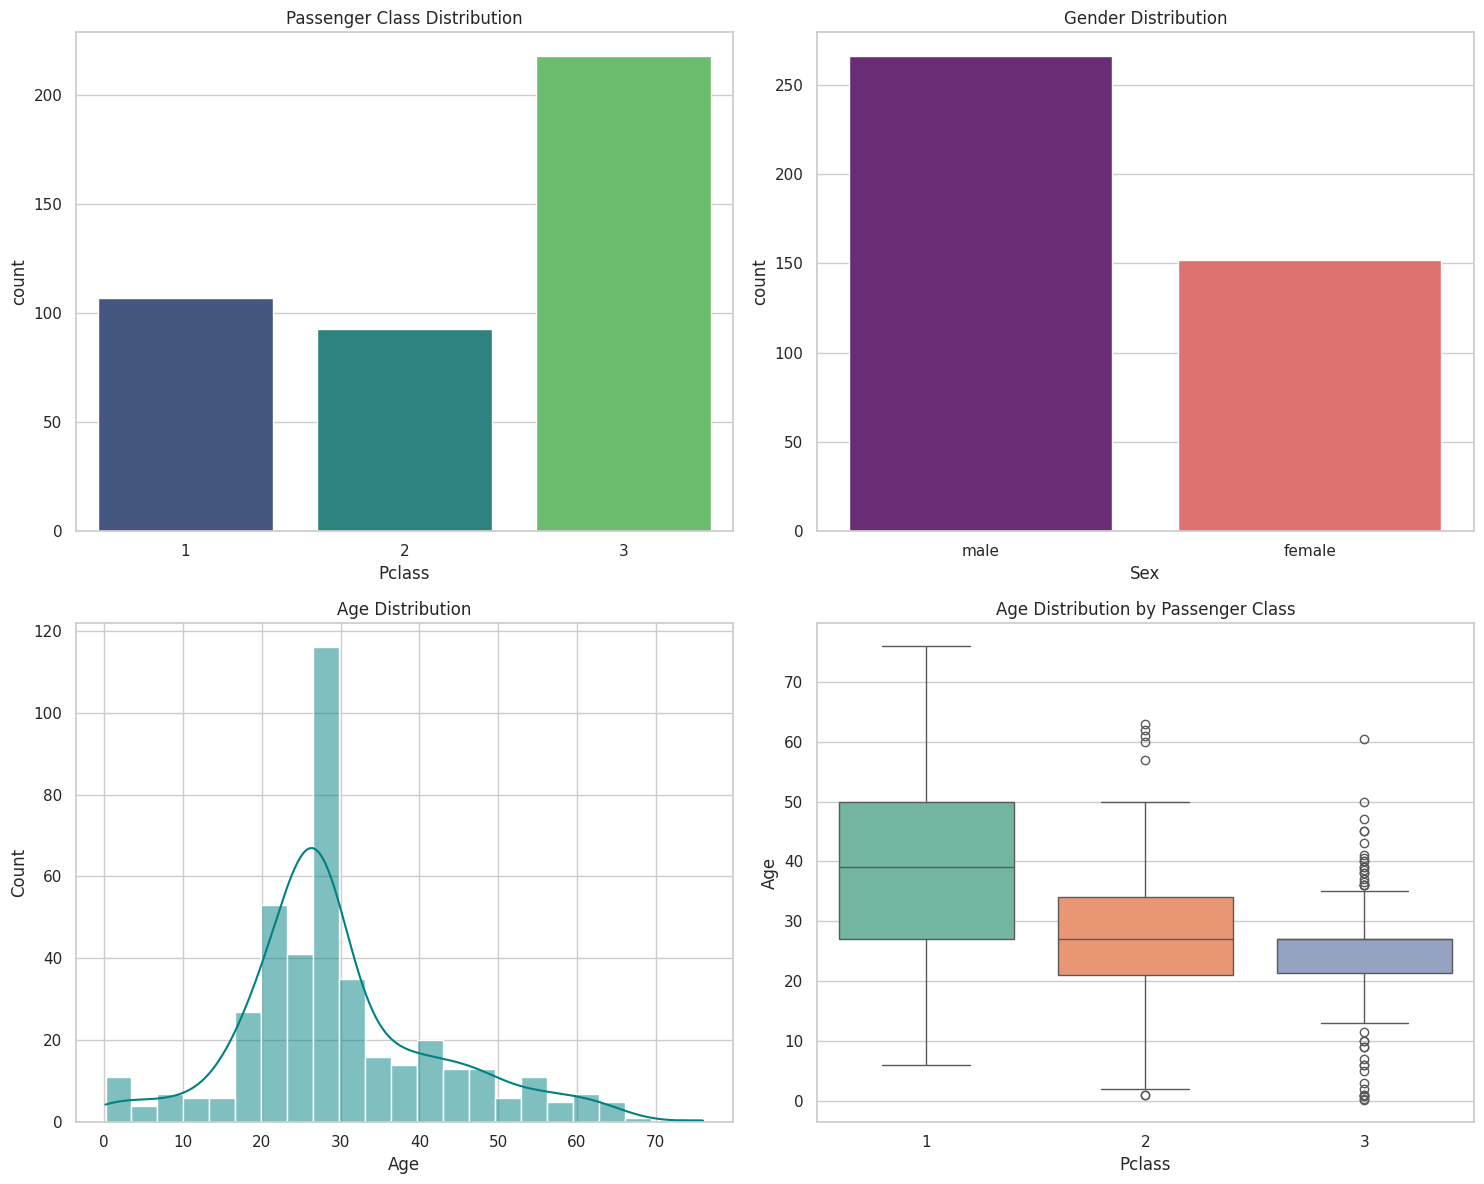


Data Pre-processing complete. Summary Statistics:
       PassengerId      Pclass         Age       SibSp       Parch        Fare
count   418.000000  418.000000  418.000000  418.000000  418.000000  418.000000
mean   1100.500000    2.265550   29.599282    0.447368    0.392344   35.576535
std     120.810458    0.841838   12.703770    0.896760    0.981429   55.850103
min     892.000000    1.000000    0.170000    0.000000    0.000000    0.000000
25%     996.250000    1.000000   23.000000    0.000000    0.000000    7.895800
50%    1100.500000    3.000000   27.000000    0.000000    0.000000   14.454200
75%    1204.750000    3.000000   35.750000    1.000000    0.000000   31.471875
max    1309.000000    3.000000   76.000000    8.000000    9.000000  512.329200


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the dataset (using test.csv as provided, but logic works for train.csv)
file_path = '/content/test.csv'
if not os.path.exists(file_path):
    print(f'File {file_path} not found. Please upload the dataset.')
else:
    df = pd.read_csv(file_path)

    # 1. Pre-processing & Handling Missing Values
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # 2. Exploratory Data Analysis & Visualizations
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Pclass Distribution
    sns.countplot(ax=axes[0, 0], x='Pclass', data=df, palette='viridis')
    axes[0, 0].set_title('Passenger Class Distribution')

    # Gender Distribution
    sns.countplot(ax=axes[0, 1], x='Sex', data=df, palette='magma')
    axes[0, 1].set_title('Gender Distribution')

    # Age Distribution
    sns.histplot(ax=axes[1, 0], x='Age', data=df, kde=True, color='teal')
    axes[1, 0].set_title('Age Distribution')

    # Survival Analysis (if 'Survived' column exists)
    if 'Survived' in df.columns:
        sns.barplot(ax=axes[1, 1], x='Pclass', y='Survived', hue='Sex', data=df, palette='Blues')
        axes[1, 1].set_title('Survival Rate by Class and Gender')
    else:
        # Alternate visualization if Survival is missing
        sns.boxplot(ax=axes[1, 1], x='Pclass', y='Age', data=df, palette='Set2')
        axes[1, 1].set_title('Age Distribution by Passenger Class')

    plt.tight_layout()
    plt.show()

    print('\nData Pre-processing complete. Summary Statistics:')
    print(df.describe())

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

file_path = '/content/train.csv'

if not os.path.exists(file_path):
    print(f'Error: {file_path} not found. Please ensure train.csv is uploaded to perform survival analysis.')
else:
    train_df = pd.read_csv(file_path)

    # Survival Rate by Pclass and Sex
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train_df, palette='muted')

    plt.title('Survival Rate by Passenger Class and Sex', fontsize=15)
    plt.xlabel('Passenger Class', fontsize=12)
    plt.ylabel('Survival Rate', fontsize=12)
    plt.legend(title='Sex')
    plt.show()

    # Displaying the exact numbers for clarity
    survival_summary = train_df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
    print('Mean Survival Rates:')
    display(survival_summary)

Error: /content/train.csv not found. Please ensure train.csv is uploaded to perform survival analysis.


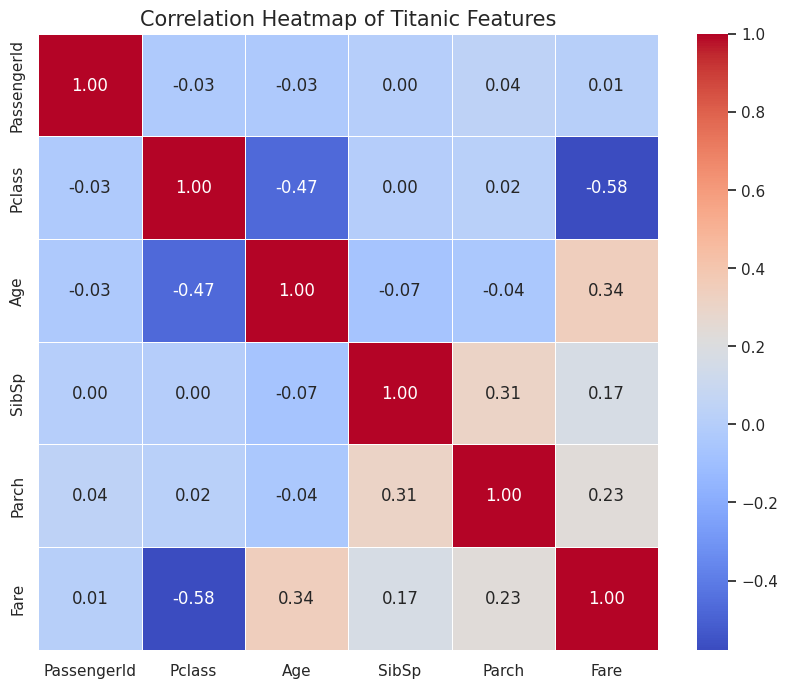

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix for numerical columns
# We use the 'df' variable from the previous processing step
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Features', fontsize=15)
plt.show()